# ICT-1 — Trajectoires de $\Phi$

> Notebook de la serie **ICT** (*Integrated Causal Trajectories*, Epic #4588).
> Cadrage de la serie : [ICT-0-Framing.md](ICT-0-Framing.md). Fondations PyPhi :
> [IIT-1-IntroToPyPhi.ipynb](IIT-1-IntroToPyPhi.ipynb).

La serie [IIT](README.md) mesure l'organisation causale d'un systeme **a un etat
donne** : sa valeur d'information integree $\Phi$. C'est une *photographie*.

Ce notebook applique la notion de **trajectoire** a $\Phi$ lui-meme. Quand un
systeme deterministe evolue, il parcourt une suite d'etats

$$ s_0 \rightarrow s_1 \rightarrow s_2 \rightarrow \dots $$

et a chaque etat correspond une valeur de $\Phi$. On obtient donc une
**trajectoire de $\Phi$** — le *film* de l'information integree pendant que le
systeme se deplace dans son espace d'etats.

Trois questions guident le notebook :

1. **Le paysage de $\Phi$** — comment $\Phi$ varie-t-il d'un etat a l'autre ?
   Est-il plat ou accidente ?
2. **La trajectoire de $\Phi$** — que devient $\Phi$ le long d'une trajectoire,
   en particulier sur l'**attracteur** ou le systeme finit par tourner ?
3. **La robustesse de $\Phi$** — apres une perturbation, la trajectoire (et donc
   le profil de $\Phi$) se reconstitue-t-elle ?

On utilise le **vrai** moteur [PyPhi](https://pyphi.readthedocs.io) pour tous les
calculs de $\Phi$ : aucun substitut, aucune valeur fabriquee. Les systemes
restent volontairement minuscules (3 noeuds, $2^3 = 8$ etats) car le calcul de
$\Phi$ est exponentiel — c'est une contrainte intrinseque de l'IIT, discutee en
conclusion.

## 0. Mise en place

On charge PyPhi et le module `ict.trajectories` (pose a cote de PyPhi, il gere
l'evolution dans l'espace d'etats sans dependre de PyPhi). On desactive le
parallelisme de PyPhi (sous Windows le `multiprocessing` provoque sinon une
avalanche de processus) et la validation des etats accessibles, pour pouvoir
calculer $\Phi$ sur **tous** les etats, y compris transitoires.

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

# le package ict est dans le dossier parent du notebook
sys.path.insert(0, os.path.abspath("."))
from ict import trajectories as T

import pyphi
pyphi.config.PROGRESS_BARS = False
pyphi.config.WELCOME_OFF = True
# calculer Phi pour n'importe quel etat (meme inaccessible / transitoire)
pyphi.config.VALIDATE_SUBSYSTEM_STATES = False
# desactiver le parallelisme (Windows : evite l'avalanche de processus)
for _attr in ("PARALLEL_CONCEPT_EVALUATION", "PARALLEL_CUT_EVALUATION",
              "PARALLEL_COMPLEX_EVALUATION", "PARALLEL"):
    if hasattr(pyphi.config, _attr):
        setattr(pyphi.config, _attr, False)

print("PyPhi", pyphi.__version__, "| numpy", np.__version__)

C:\ProgramData\miniconda3\envs\pyphi\lib\site-packages\pyemd\__init__.py:74: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from .emd import emd, emd_with_flow, emd_samples



Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'

PyPhi 1.2.0 | numpy 1.26.4


### Deux reseaux a 3 noeuds

On compare deux architectures causales deterministes, toutes deux integrees mais
de structures tres differentes :

- **AND/OR** : un petit reseau ou les noeuds combinent leurs entrees par des
  portes logiques mixtes.
- **XOR** : l'exemple canonique de PyPhi, ou chaque noeud est le OU-exclusif des
  deux autres — un reseau tres symetrique.

Pour chacun, `network.tpm` est la matrice de transition au format *state-by-node*
de PyPhi : indexee par un tuple d'etat, elle donne l'etat suivant (les reseaux
sont deterministes).

In [2]:
# reseau AND/OR (TPM state-by-node, lignes indexees en little-endian)
andor_tpm = np.array([
    [0, 0, 0], [0, 0, 1], [1, 0, 1], [1, 0, 0],
    [1, 1, 0], [1, 1, 1], [1, 1, 1], [1, 1, 0],
])
andor = pyphi.Network(andor_tpm, node_labels=['A', 'B', 'C'])

# reseau XOR : exemple fourni par PyPhi
xor = pyphi.examples.xor_network()

print("AND/OR : noeuds", andor.node_labels, "| matrice de connectivite\n", andor.cm)
print("\nXOR    : noeuds", xor.node_labels, "| matrice de connectivite\n", xor.cm)

AND/OR : noeuds NodeLabels(('A', 'B', 'C')) | matrice de connectivite
 [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]

XOR    : noeuds NodeLabels(('A', 'B', 'C')) | matrice de connectivite
 [[0 1 1]
 [1 0 1]
 [1 1 0]]


## 1. Le paysage de $\Phi$

$\Phi$ depend du systeme **et de son etat**. Avant de parler de trajectoire,
cartographions $\Phi$ sur **tous** les etats : c'est le *paysage de $\Phi$*.

La fonction ci-dessous calcule $\Phi$ pour chacun des $2^n$ etats. C'est le seul
endroit ou PyPhi travaille vraiment ; le reste du notebook ne fait que relire
cette carte.

In [3]:
def phi_landscape(network, n):
    # carte etat (tuple) -> Phi (float), calculee par PyPhi sur tous les etats
    nodes = tuple(range(n))
    carte = {}
    for s in T.all_states(n):
        sub = pyphi.Subsystem(network, s, nodes)
        carte[s] = float(pyphi.compute.phi(sub))
    return carte

land_andor = phi_landscape(andor, 3)
land_xor = phi_landscape(xor, 3)

def resume(carte, nom):
    v = list(carte.values())
    print(f"{nom:8s} min={min(v):.4f}  max={max(v):.4f}  "
          f"moyenne={sum(v)/len(v):.4f}  amplitude={max(v)-min(v):.4f}")

for s in T.all_states(3):
    print(f"  etat {s} : AND/OR Phi={land_andor[s]:.4f}   XOR Phi={land_xor[s]:.4f}")
print()
resume(land_andor, "AND/OR")
resume(land_xor, "XOR")

  etat (0, 0, 0) : AND/OR Phi=0.1875   XOR Phi=1.8750
  etat (1, 0, 0) : AND/OR Phi=2.3125   XOR Phi=1.8750
  etat (0, 1, 0) : AND/OR Phi=0.1875   XOR Phi=1.8750
  etat (1, 1, 0) : AND/OR Phi=0.1875   XOR Phi=1.8750
  etat (0, 0, 1) : AND/OR Phi=0.1875   XOR Phi=1.8750
  etat (1, 0, 1) : AND/OR Phi=0.6875   XOR Phi=1.8750
  etat (0, 1, 1) : AND/OR Phi=0.1875   XOR Phi=1.8750
  etat (1, 1, 1) : AND/OR Phi=0.1875   XOR Phi=1.8750

AND/OR   min=0.1875  max=2.3125  moyenne=0.5156  amplitude=2.1250
XOR      min=1.8750  max=1.8750  moyenne=1.8750  amplitude=0.0000


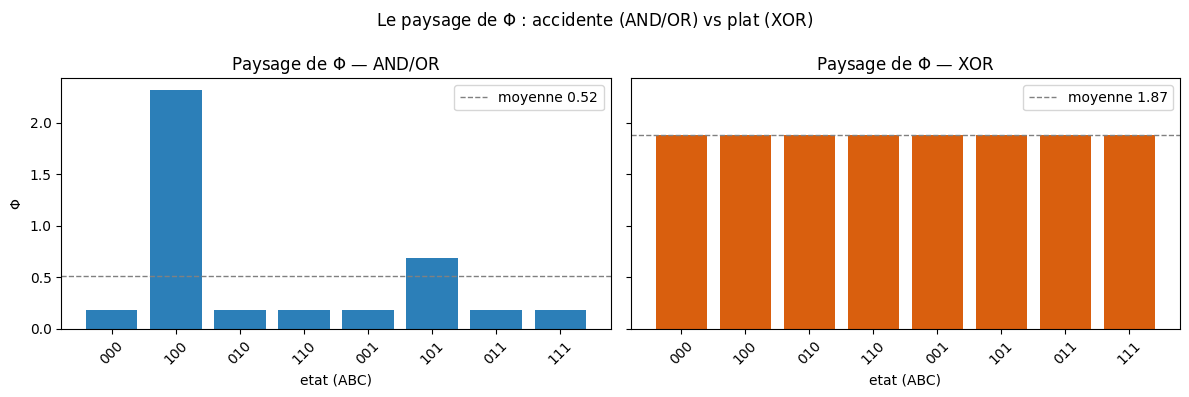

In [4]:
# visualisation des deux paysages de Phi
labels = ["".join(map(str, s)) for s in T.all_states(3)]
x = np.arange(8)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, carte, nom, col in [(axes[0], land_andor, "AND/OR", "#2c7fb8"),
                            (axes[1], land_xor, "XOR", "#d95f0e")]:
    vals = [carte[s] for s in T.all_states(3)]
    ax.bar(x, vals, color=col)
    ax.set_title(f"Paysage de $\\Phi$ — {nom}")
    ax.set_xlabel("etat (ABC)")
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45)
    ax.axhline(np.mean(vals), color="gray", ls="--", lw=1,
               label=f"moyenne {np.mean(vals):.2f}")
    ax.legend()
axes[0].set_ylabel("$\\Phi$")
fig.suptitle("Le paysage de $\\Phi$ : accidente (AND/OR) vs plat (XOR)")
plt.tight_layout()
plt.show()

**Lecture.** Les deux paysages sont radicalement differents :

- **AND/OR** est **accidente** : la plupart des etats ont un $\Phi$ faible
  ($\approx 0{,}19$), mais un etat — `100`, soit $A$ seul actif — culmine a
  $\Phi \approx 2{,}31$, et `101` forme un relief intermediaire ($\approx 0{,}69$).
  L'information integree du systeme **depend fortement de l'etat ou il se trouve**.
- **XOR** est un **plateau** : $\Phi = 1{,}875$ pour *tous* les etats (amplitude
  nulle). La symetrie du OU-exclusif rend l'information integree **independante de
  l'etat**.

Un meme nombre de noeuds, deux "personnalites causales" opposees. C'est ce
paysage qui va donner son relief aux trajectoires de $\Phi$.

## 2. La trajectoire de $\Phi$

Un reseau deterministe, lache depuis un etat de depart, suit un chemin unique
jusqu'a tomber dans un **attracteur** (un point fixe ou un cycle). Le module
`ict.trajectories` reconstruit ce chemin en lisant la TPM, puis on relit la carte
de $\Phi$ le long du chemin.

In [5]:
# trajectoires de quelques etats de depart du reseau AND/OR
departs = [(0, 0, 0), (1, 0, 0), (0, 1, 0), (1, 1, 1)]
for start in departs:
    path, debut = T.state_trajectory(andor.tpm, start)
    attr = T.attractor_of(andor.tpm, start)
    phis = T.phi_trajectory(land_andor, path)
    print(f"depart {start} -> chemin {path}")
    print(f"   attracteur {attr}")
    print(f"   Phi le long : {[round(p, 3) for p in phis]}\n")

print("Bassins d'attraction (signature attracteur -> nb d'etats de depart) :")
print("  AND/OR :", T.basin_sizes(andor.tpm, 3))
print("  XOR    :", T.basin_sizes(xor.tpm, 3))

depart (0, 0, 0) -> chemin [(0, 0, 0), (0, 0, 0)]
   attracteur [(0, 0, 0)]
   Phi le long : [0.188, 0.188]

depart (1, 0, 0) -> chemin [(1, 0, 0), (0, 0, 1), (1, 1, 0), (1, 0, 0)]
   attracteur [(1, 0, 0), (0, 0, 1), (1, 1, 0)]
   Phi le long : [2.312, 0.188, 0.188, 2.312]

depart (0, 1, 0) -> chemin [(0, 1, 0), (1, 0, 1), (1, 1, 1), (1, 1, 0), (1, 0, 0), (0, 0, 1), (1, 1, 0)]
   attracteur [(1, 1, 0), (1, 0, 0), (0, 0, 1)]
   Phi le long : [0.188, 0.687, 0.188, 0.188, 2.312, 0.188, 0.188]

depart (1, 1, 1) -> chemin [(1, 1, 1), (1, 1, 0), (1, 0, 0), (0, 0, 1), (1, 1, 0)]
   attracteur [(1, 1, 0), (1, 0, 0), (0, 0, 1)]
   Phi le long : [0.188, 0.188, 2.312, 0.188, 0.188]

Bassins d'attraction (signature attracteur -> nb d'etats de depart) :
  AND/OR : {((0, 0, 0),): 1, ((0, 0, 1), (1, 0, 0), (1, 1, 0)): 7}
  XOR    : {((0, 0, 0),): 2, ((0, 1, 1),): 2, ((1, 0, 1),): 2, ((1, 1, 0),): 2}


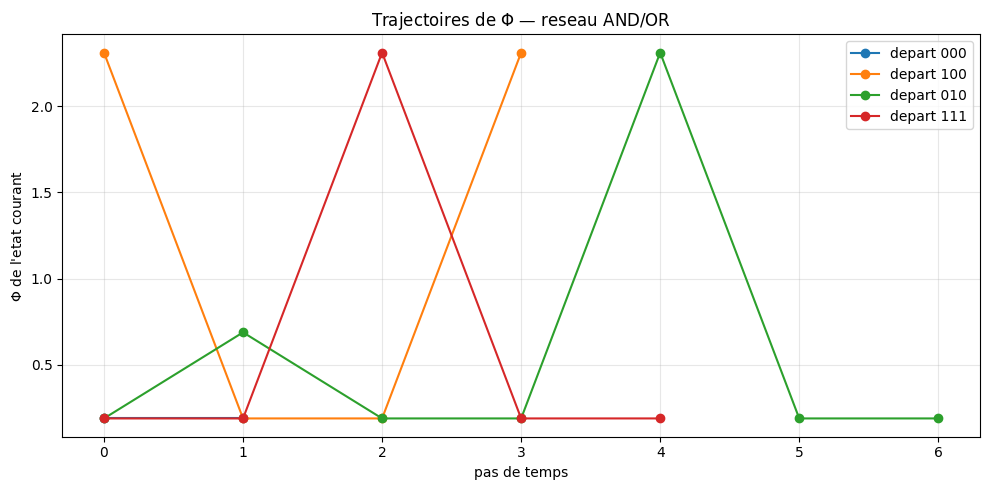

In [6]:
# Phi le long des trajectoires AND/OR (le 'film' de l'information integree)
fig, ax = plt.subplots(figsize=(10, 5))
for start in departs:
    path, _ = T.state_trajectory(andor.tpm, start)
    phis = T.phi_trajectory(land_andor, path)
    ax.plot(range(len(phis)), phis, marker="o",
            label=f"depart {''.join(map(str, start))}")
ax.set_title("Trajectoires de $\\Phi$ — reseau AND/OR")
ax.set_xlabel("pas de temps")
ax.set_ylabel("$\\Phi$ de l'etat courant")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Lecture.** Le resultat le plus parlant concerne l'**attracteur** du reseau
AND/OR. Sept des huit etats finissent dans le **meme cycle de longueur 3** :

$$ 100 \rightarrow 001 \rightarrow 110 \rightarrow 100 \rightarrow \dots $$

et la trajectoire de $\Phi$ sur ce cycle **pulse** : $2{,}31 \rightarrow 0{,}19
\rightarrow 0{,}19 \rightarrow 2{,}31 \dots$ L'information integree n'est donc
**pas un badge fixe** du systeme : elle monte en fleche un pas sur trois, quand le
systeme traverse l'etat-pic `100`, puis retombe. Un systeme dynamique peut etre
"fortement integre par intermittence".

Le huitieme etat, `000`, est un **point fixe** isole ($\Phi$ constant a $0{,}19$) :
un petit bassin a part. Sur XOR, au contraire, toutes les trajectoires atteignent
un point fixe en un ou deux pas, et comme le paysage est plat, $\Phi$ y reste
**rigoureusement constant** a $1{,}875$ : un film sans relief.

## 3. Robustesse : $\Phi$ apres une perturbation

La serie ICT s'interesse aux trajectoires qui **se reparent** (cf. ICT-2/ICT-3
pour le toy-model de tri). Posons ici la meme question avec de l'information
integree *reelle* : si l'on perturbe le systeme une fois installe sur son
attracteur, sa trajectoire de $\Phi$ se reconstitue-t-elle ?

On part du cycle AND/OR, on bascule **un seul noeud** (perturbation 1-bit), puis
on laisse le systeme re-evoluer.

attracteur de reference : [(1, 1, 0), (1, 0, 0), (0, 0, 1)]
etat perturbe : (1, 1, 0)

flip noeud 0 : (1, 1, 0) -> (0, 1, 0) | retour au meme attracteur : True
flip noeud 1 : (1, 1, 0) -> (1, 0, 0) | retour au meme attracteur : True
flip noeud 2 : (1, 1, 0) -> (1, 1, 1) | retour au meme attracteur : True


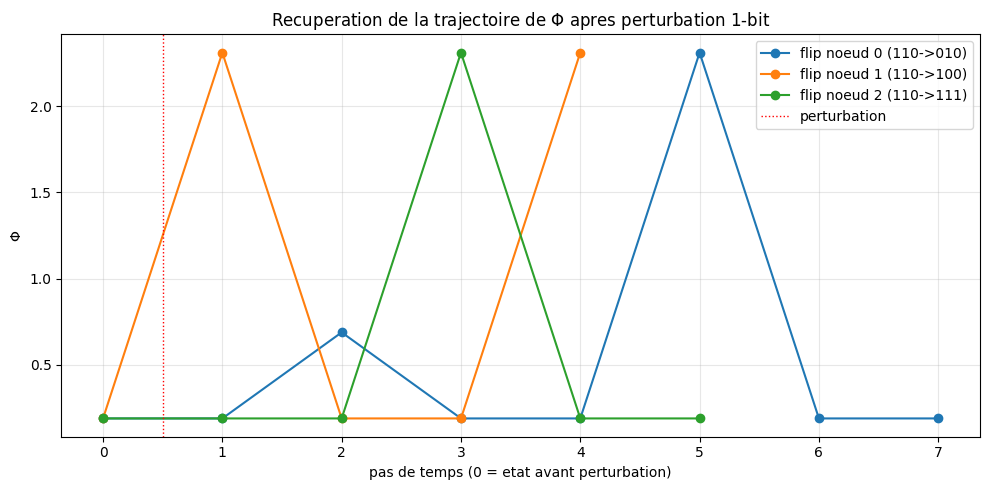

In [7]:
# perturbation 1-bit a partir d'un etat de l'attracteur, puis recuperation
attr = T.attractor_of(andor.tpm, (1, 1, 1))
base = attr[0]                       # un etat du cycle attracteur
print(f"attracteur de reference : {attr}")
print(f"etat perturbe : {base}\n")

fig, ax = plt.subplots(figsize=(10, 5))
for bit in range(3):
    pert = T.flip_bit(base, bit)
    path, _ = T.state_trajectory(andor.tpm, pert)
    # on prefixe l'etat de base pour visualiser le 'saut' de la perturbation
    phis = T.phi_trajectory(land_andor, [base] + path)
    retour = tuple(sorted(T.attractor_of(andor.tpm, pert))) == tuple(sorted(attr))
    print(f"flip noeud {bit} : {base} -> {pert} | "
          f"retour au meme attracteur : {retour}")
    ax.plot(range(len(phis)), phis, marker="o",
            label=f"flip noeud {bit} ({''.join(map(str, base))}->{''.join(map(str, pert))})")

ax.axvline(0.5, color="red", ls=":", lw=1, label="perturbation")
ax.set_title("Recuperation de la trajectoire de $\\Phi$ apres perturbation 1-bit")
ax.set_xlabel("pas de temps (0 = etat avant perturbation)")
ax.set_ylabel("$\\Phi$")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Lecture.** Les **trois** perturbations 1-bit possibles depuis l'etat `110`
du cycle ramenent le systeme **au meme attracteur** : la trajectoire de $\Phi$ se
reconstitue dans tous les cas. Le profil pulsatile de $\Phi$ est donc une
propriete **robuste** de la dynamique, pas un accident de l'etat initial.

Les chemins de retour different : basculer le noeud 1 (`110 \to 100`) place
directement le systeme sur l'etat-pic, et $\Phi$ remonte immediatement a $2{,}31$ ;
basculer le noeud 0 (`110 \to 010`) impose un detour plus long avant que le pic ne
revienne. La *forme* du transitoire depend de la perturbation, mais la
*destination* — le cycle et son profil de $\Phi$ — est invariante.

## 4. Exercices

Trois exercices pour manipuler vous-meme le paysage et les trajectoires de $\Phi$.
Completez le corps de chaque fonction (remplacez le `return None`). Le notebook
s'execute de bout en bout meme sans les completer.

### Exercice 1 — Amplitude du paysage de $\Phi$

Le paysage AND/OR est accidente (amplitude $\approx 2{,}12$), celui de XOR est
plat (amplitude $0$). Ecrivez une fonction qui **mesure** cet ecart : l'amplitude
$\max \Phi - \min \Phi$ sur tout le paysage d'un reseau.

In [8]:
def phi_amplitude(network, n):
    # Objectif : retourner max(Phi) - min(Phi) sur les 2**n etats du reseau.
    # Indice : reutiliser phi_landscape(network, n) defini en section 1.
    # Indice : amplitude = max(carte.values()) - min(carte.values()).
    # Etape etudiant :
    result = None  # TODO etudiant : calculer l'amplitude du paysage
    return result

amp = phi_amplitude(andor, 3)
if amp is not None:
    print(f"Amplitude du paysage AND/OR : {amp:.4f}")
else:
    print("Exercice a completer")

Exercice a completer


### Exercice 2 — $\Phi$ moyen sur l'attracteur

Sur le cycle AND/OR, $\Phi$ pulse ($2{,}31 \to 0{,}19 \to 0{,}19$). Le $\Phi$
*moyen* sur l'attracteur resume "l'integration soutenue" d'un regime. Ecrivez une
fonction qui, depuis un etat de depart, retourne la moyenne de $\Phi$ sur les
etats du cycle attracteur.

In [9]:
def mean_phi_on_attractor(tpm, phi_map, start):
    # Objectif : moyenne de Phi sur les etats de l'attracteur atteint depuis start.
    # Indice : attr = T.attractor_of(tpm, start) donne la liste des etats du cycle.
    # Indice : phi_map[etat] donne Phi de chaque etat ; faire la moyenne.
    # Etape etudiant :
    result = None  # TODO etudiant : moyenne de Phi sur l'attracteur
    return result

m = mean_phi_on_attractor(andor.tpm, land_andor, (1, 1, 1))
if m is not None:
    print(f"Phi moyen sur l'attracteur AND/OR : {m:.4f}")
else:
    print("Exercice a completer")

Exercice a completer


### Exercice 3 — Compter les pulsations de $\Phi$

Un "pic" de $\Phi$ le long d'une trajectoire est un **maximum local**. La fonction
`T.detect_events` renvoie les indices des minima et maxima locaux d'une courbe.
Ecrivez une fonction qui compte le nombre de **pics** de $\Phi$ le long de la
trajectoire issue d'un etat de depart.

In [10]:
def count_phi_pulses(tpm, phi_map, start):
    # Objectif : nombre de maxima locaux (pics de Phi) le long de la trajectoire.
    # Indice : path, _ = T.state_trajectory(tpm, start) donne le chemin d'etats.
    # Indice : phis = T.phi_trajectory(phi_map, path) donne la courbe de Phi.
    # Indice : T.detect_events(phis)["maxima"] est la liste des indices de pics.
    # Etape etudiant :
    result = None  # TODO etudiant : compter les pics (len des maxima)
    return result

n_pulses = count_phi_pulses(andor.tpm, land_andor, (0, 1, 0))
if n_pulses is not None:
    print(f"Nombre de pics de Phi (depart 010) : {n_pulses}")
else:
    print("Exercice a completer")

Exercice a completer


## 5. Conclusion

En appliquant la notion de **trajectoire** a $\Phi$ lui-meme, on a vu que :

1. **$\Phi$ a un paysage.** Pour un meme nombre de noeuds, ce paysage peut etre
   accidente (AND/OR : un pic a $2{,}31$, le reste a $0{,}19$) ou parfaitement plat
   (XOR : $1{,}875$ partout). L'information integree est une fonction de l'etat,
   pas seulement du cablage.
2. **$\Phi$ a une trajectoire.** Sur l'attracteur d'AND/OR — un cycle de longueur
   3 — $\Phi$ **pulse**. Un systeme peut donc etre *integre par intermittence* :
   l'integration est un evenement dans le temps, pas une etiquette permanente.
3. **La trajectoire de $\Phi$ est robuste.** Les trois perturbations 1-bit du
   cycle ramenent au meme attracteur : le profil pulsatile de $\Phi$ se repare.

**La limite intrinseque.** Tous les systemes de ce notebook ont 3 noeuds. Le
calcul de $\Phi$ est **super-exponentiel** : il faut considerer toutes les
partitions du systeme pour chaque etat. Au-dela d'une dizaine de noeuds, PyPhi
devient impraticable. C'est *la* raison pour laquelle l'IIT exacte se cantonne aux
petits systemes — et c'est le probleme que les notebooks suivants attaquent :

- **ICT-5/ICT-6** : trouver une **macro-description** (coarse-graining,
  pont tri $\to$ TPM) ou $\Phi$ redevient calculable a plus grande echelle.
- **ICT-2/ICT-3** : etudier des trajectoires riches sur des modeles *jouets*
  (tri auto-organise) qui se passent de PyPhi, quand le systeme est trop grand
  pour l'IIT exacte.

Conformement au principe de la serie ([ICT-0](ICT-0-Framing.md)) : tout ce qui
precede a ete **calcule par le vrai PyPhi**, puis narre tel quel.

## Voir aussi

- [ICT-0-Framing.md](ICT-0-Framing.md) — cadrage de la serie ICT.
- [IIT-1-IntroToPyPhi.ipynb](IIT-1-IntroToPyPhi.ipynb) — TPM, sous-systeme, $\Phi$, CES.
- [ICT-2-SelfSortingMorphogenesis.ipynb](ICT-2-SelfSortingMorphogenesis.ipynb) /
  [ICT-3-RobustnessDelayedGratification.ipynb](ICT-3-RobustnessDelayedGratification.ipynb)
  — trajectoires et robustesse sur le toy-model de tri.
- Zhang, Goldstein & Levin (2025), *Classical sorting algorithms as a model of
  morphogenesis*, [arXiv:2401.05375](https://arxiv.org/abs/2401.05375).